In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns

## Data import and general checking

In [16]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [17]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [18]:
train_df.dtypes[train_df.dtypes != object]

PassengerId      int64
Survived         int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
dtype: object

In [19]:
train_df.dtypes[train_df.dtypes == object]

Name        object
Sex         object
Ticket      object
Cabin       object
Embarked    object
dtype: object

## Plotting

Since this is a classification problem, we dont use scatter plot. We use
- Histplot for continuos feature ( Age, Fare, etc)
- Barplot for categorial feature ( Sex, Pclass, etc) and outlier

<Axes: xlabel='Pclass', ylabel='Survived'>

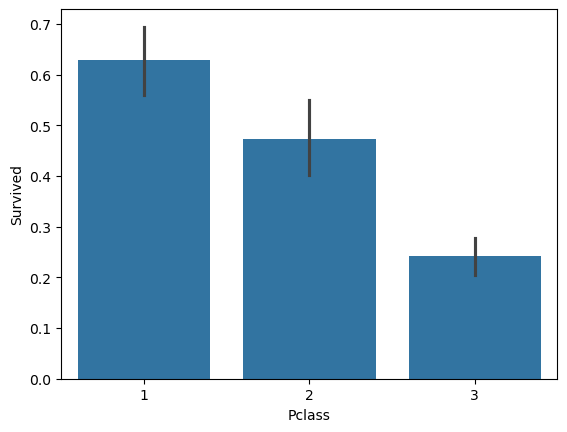

In [46]:
sns.barplot(data=train_df, x='Pclass', y='Survived', estimator='mean') #barplot calculates mean by default, but can change to sum or median

<Axes: xlabel='Age', ylabel='Count'>

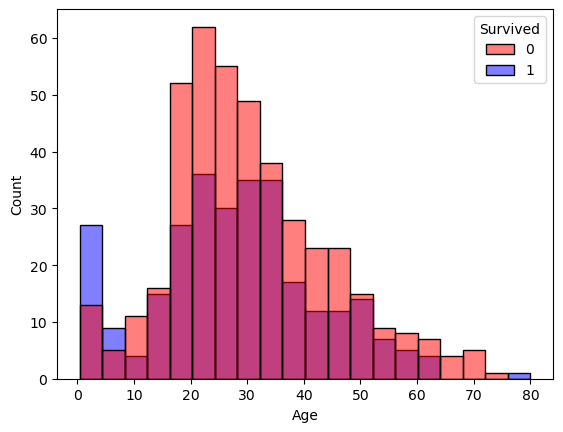

In [ ]:
sns.histplot(data=train_df, x='Age', hue='Survived',palette=['red', 'blue'])

<Axes: xlabel='SibSp', ylabel='Count'>

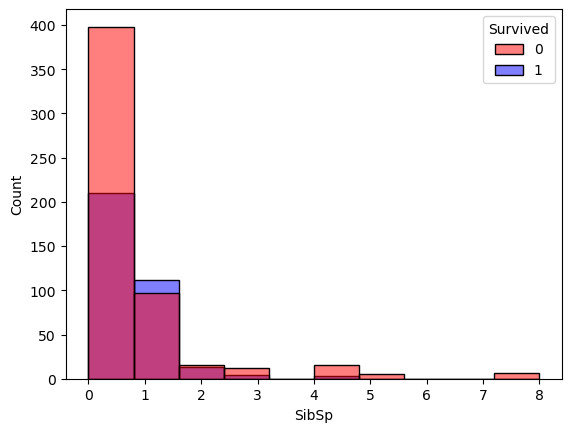

In [41]:
sns.histplot(data=train_df, x='SibSp', bins=10, hue='Survived',palette=['red', 'blue'])

<Axes: xlabel='Fare', ylabel='Count'>

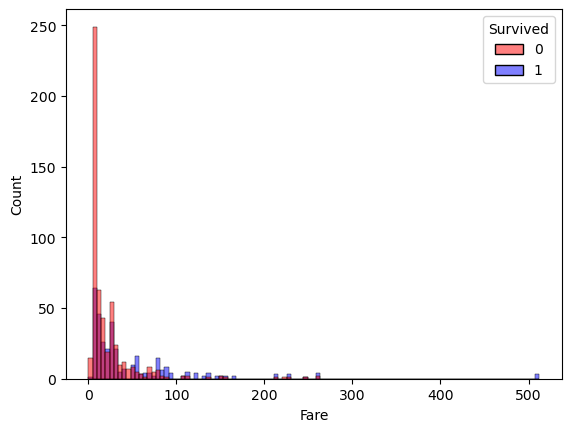

In [43]:
sns.histplot(data=train_df, x='Fare', hue='Survived', palette=['red', 'blue'])

<Axes: xlabel='Sex', ylabel='Survived'>

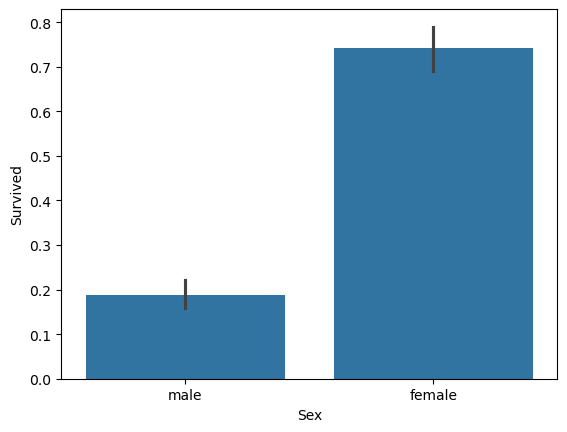

In [44]:
sns.barplot(data=train_df, x='Sex', y='Survived')

<Axes: xlabel='Sex', ylabel='count'>

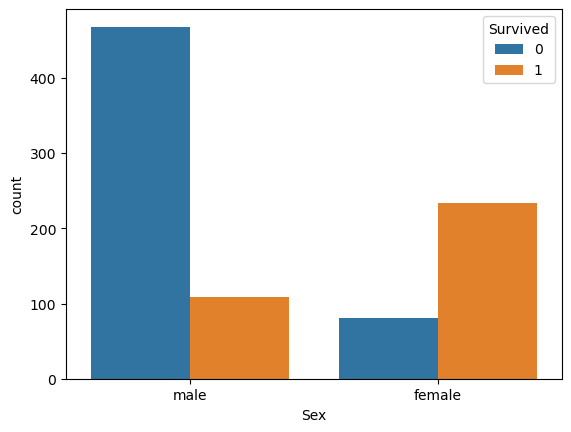

In [45]:
sns.countplot(data=train_df, x='Sex', hue='Survived')

<Axes: xlabel='Ticket', ylabel='Count'>

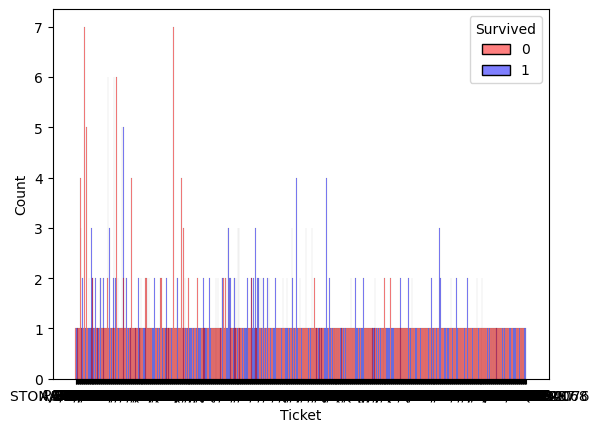

In [47]:
sns.histplot(data=train_df, x='Ticket', hue='Survived', palette=['red', 'blue'])

<Axes: xlabel='Pclass', ylabel='count'>

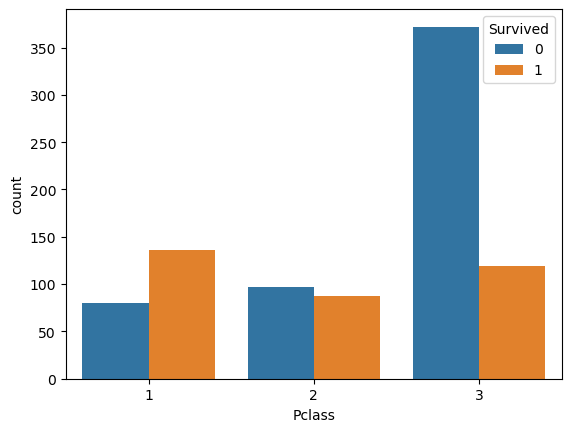

In [49]:
sns.countplot(data=train_df, x='Pclass', hue='Survived')

In [52]:
sorted(train_df['Cabin'].dropna().unique())

['A10',
 'A14',
 'A16',
 'A19',
 'A20',
 'A23',
 'A24',
 'A26',
 'A31',
 'A32',
 'A34',
 'A36',
 'A5',
 'A6',
 'A7',
 'B101',
 'B102',
 'B18',
 'B19',
 'B20',
 'B22',
 'B28',
 'B3',
 'B30',
 'B35',
 'B37',
 'B38',
 'B39',
 'B4',
 'B41',
 'B42',
 'B49',
 'B5',
 'B50',
 'B51 B53 B55',
 'B57 B59 B63 B66',
 'B58 B60',
 'B69',
 'B71',
 'B73',
 'B77',
 'B78',
 'B79',
 'B80',
 'B82 B84',
 'B86',
 'B94',
 'B96 B98',
 'C101',
 'C103',
 'C104',
 'C106',
 'C110',
 'C111',
 'C118',
 'C123',
 'C124',
 'C125',
 'C126',
 'C128',
 'C148',
 'C2',
 'C22 C26',
 'C23 C25 C27',
 'C30',
 'C32',
 'C45',
 'C46',
 'C47',
 'C49',
 'C50',
 'C52',
 'C54',
 'C62 C64',
 'C65',
 'C68',
 'C7',
 'C70',
 'C78',
 'C82',
 'C83',
 'C85',
 'C86',
 'C87',
 'C90',
 'C91',
 'C92',
 'C93',
 'C95',
 'C99',
 'D',
 'D10 D12',
 'D11',
 'D15',
 'D17',
 'D19',
 'D20',
 'D21',
 'D26',
 'D28',
 'D30',
 'D33',
 'D35',
 'D36',
 'D37',
 'D45',
 'D46',
 'D47',
 'D48',
 'D49',
 'D50',
 'D56',
 'D6',
 'D7',
 'D9',
 'E10',
 'E101',
 'E12',
 

<Axes: xlabel='Cabin', ylabel='Count'>

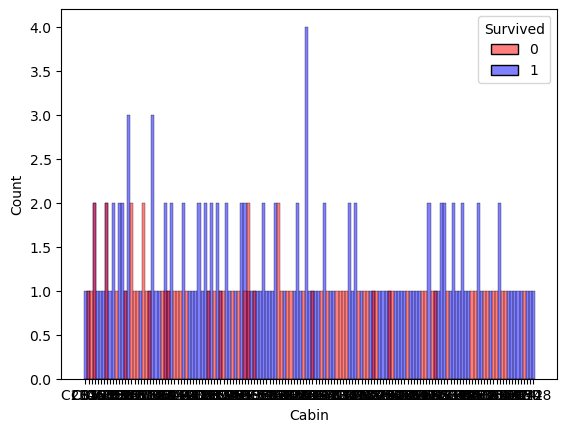

In [53]:
sns.histplot(data=train_df, x='Cabin', hue='Survived', palette=['red', 'blue'])

## Checking Null Values

In [55]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Handling Null values

As we can see age and embarked have null values. We fill them up with Median instead of mean because age might be skewed.
- Dont worry about Cabin as it will be dropped later

In [67]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

In [68]:
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

### Dropping Columns

Here we are dropping PassengerId, Name, Ticket, Cabin. 

How do we know what to drop before we even check the correlation?

At this stage, we are just using common sense as we know things like name and ticket and passangerId will have no effect on survival. While cabin might have effect on survival becuase some cabin will have more survival kits, but becuase it has too many null values which makes the data unreliable 

In [63]:
train_df = train_df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])

In [66]:
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Now we want to check correlation of each feature, but becuase some of them are string, corr() wont work, so we need to encode them first using one hot encoding

## Feature Engineering

In [54]:
train_df.corr()['Survived']
sns.heatmap(train_df.corr())

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'